# Valores atípicos

## Identificación y tratamiento de valores atípicos en datos espaciales

## Caso de uso: Inspección de valores atípicos en datos espaciales para la construcción de un índice de densidad urbana en Chinchiná

Para el municipio de Chinchiná, se busca construir un índice de compactación urbana (ICU)a utilizando variables del Marco Geoestadístico Nacional a nivel de manzana. Antes de calcular el índice, se detectarán valores atípicos para evitar que afecten los resultados.

### Análisis del Problema

**Objetivo:** Identificar y analizar valores atípicos en las variables del Marco Geoestadístico Nacional.

**Conceptos**
- Valores atípicos.
- Valores atípicos globales.
- Valores atípicos locales.
- Métodos de detección de valores atípicos.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os

In [2]:

os.chdir("/content")

In [3]:
%%capture
#Crear carpeta para almacenar insumos
os.makedirs("/content/1_insumos", exist_ok=True)

#Descargar el ZIP desde GitHub
!wget https://github.com/Luisafrodriguezo1/Diplomado-OT-2026/raw/refs/heads/main/RecursosVA.zip -O /content/1_insumos/RecursosVA.zip

#Descomprimir
!unzip /content/1_insumos/RecursosVA.zip -d /content/1_insumos


In [4]:
mzn_dane=gpd.read_file(r"1_insumos/Recursos/mzn_procesada.shp")
mzn_dane = mzn_dane[['TVIVIENDA', 'TP27_PERSO', 'AREA', 'geometry']]
print("Tamaño de la capa",mzn_dane.shape)
mzn_dane.head(30)

Tamaño de la capa (622, 4)


,TVIVIENDA,TP27_PERSO,AREA,geometry
0,27.0,79.0,6414.624086,"POLYGON ((-75.60506 4.99036, -75.60506 4.99036..."
1,23.0,56.0,3322.581474,"POLYGON ((-75.60769 4.98821, -75.60769 4.98821..."
2,0.0,0.0,1644.960978,"POLYGON ((-75.60779 4.98796, -75.6079 4.98799,..."
3,4.0,11.0,5997.563014,"POLYGON ((-75.60692 4.98771, -75.60692 4.98769..."
4,0.0,0.0,1375.185582,"POLYGON ((-75.60612 4.98743, -75.60613 4.98743..."
5,0.0,0.0,26839.593306,"POLYGON ((-75.60897 4.99113, -75.60895 4.99113..."
6,46.0,113.0,17844.886650,"POLYGON ((-75.61029 4.99007, -75.61029 4.99029..."
7,19.0,34.0,1093.318635,"POLYGON ((-75.61447 4.99763, -75.61448 4.99763..."
8,0.0,0.0,16951.099514,"POLYGON ((-75.61313 4.99259, -75.61314 4.99267..."
9,0.0,0.0,11547.281815,"POLYGON ((-75.61348 4.99219, -75.61358 4.99232..."


Tamaño de la capa es 635 filas y 4 columnas.

Se genera un resumen estadístico de las variables del `GeoDataFrame`.

In [5]:
info=mzn_dane.describe()
info

,TVIVIENDA,TP27_PERSO,AREA
count,622.000000,622.000000,622.000000
mean,25.064309,70.095498,5495.632076
std,22.046336,60.840575,15154.706764
min,0.000000,0.000000,126.092100
25%,9.000000,24.000000,979.459514
50%,21.000000,59.000000,1830.092215
75%,34.000000,99.000000,3560.555261
max,142.000000,397.000000,206593.201361


Se calcula la mediana de las variables seleccionadas. La mediana es una medida de tendencia central que representa el valor central de un conjunto de datos ordenados. A diferencia de la media, la mediana no se ve fuertemente afectada por valores atípicos.

In [6]:
variables=mzn_dane[['TVIVIENDA','TP27_PERSO','AREA']]
medianas = variables.median()
print(medianas)

TVIVIENDA       21.000000
TP27_PERSO      59.000000
AREA          1830.092215
dtype: float64


Se identifica si existen valores nulos en las variables.Los valores nulos pueden afectar cálculos estadísticos, dificultar la detección de valores atípicos y generar errores en modelos de machine learning. Por eso, es necesario identificarlos y tratarlos antes del análisis.

In [7]:
mzn_dane.isna().sum()

,0
TVIVIENDA,0
TP27_PERSO,0
AREA,0
geometry,0


#### Análisis valores atípicos globales:

Se visualiza la distribución de las variables.

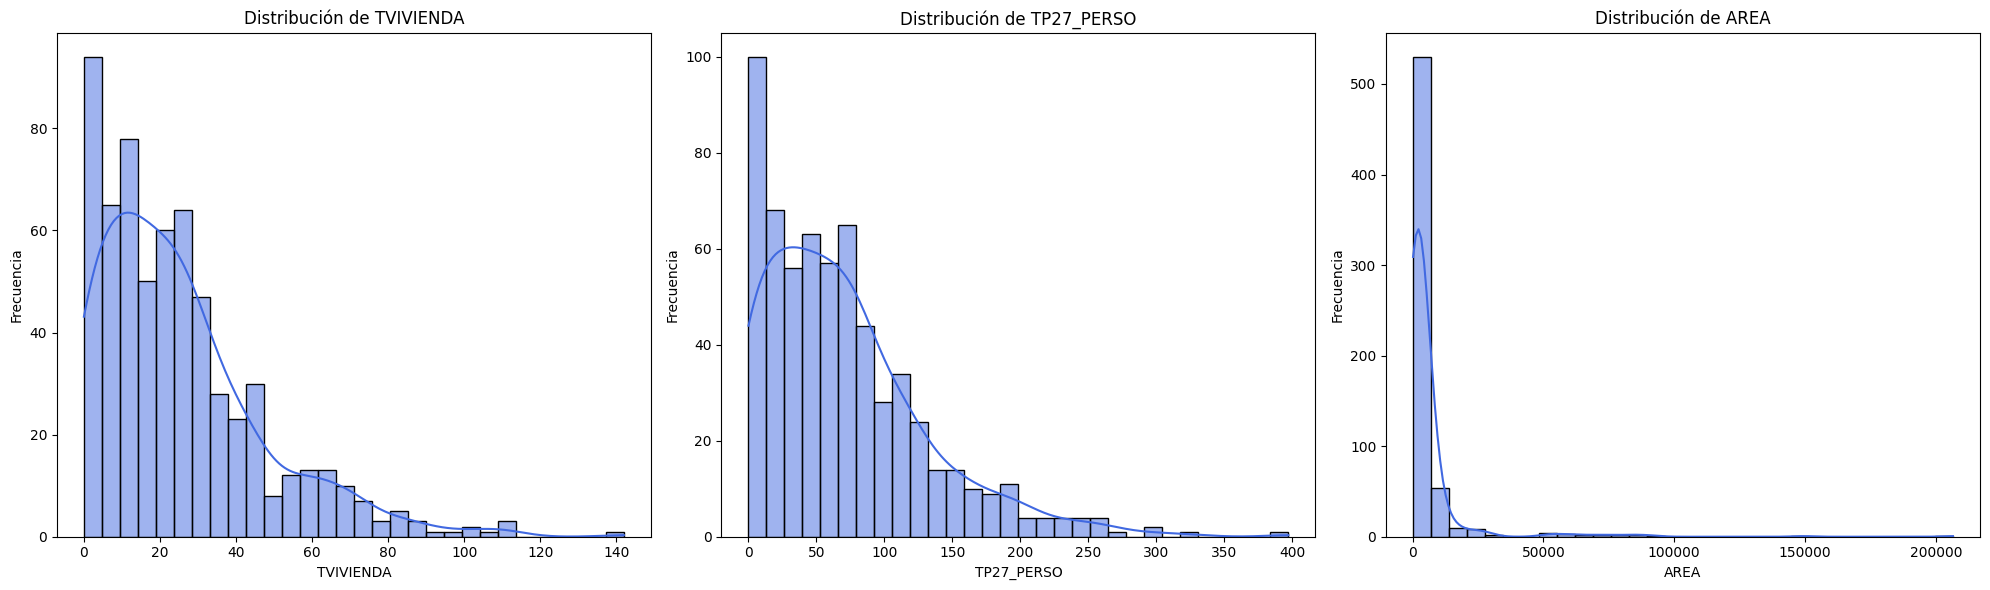

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['TVIVIENDA', 'TP27_PERSO', 'AREA']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, var in enumerate(variables):
    sns.histplot(mzn_dane[var], bins=30, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Las variables `TVIVIENDA` y `TP27_PERSO` no son continuas, mientras que `AREA` sí lo es, aunque su distribución no sigue una distribución normal. Por esta razón, la detección de valores atípicos se realizará mediante el rango intercuartílico (IQR).

Ahora, visualicemos el boxplot para analizar la presencia de valores atípicos.

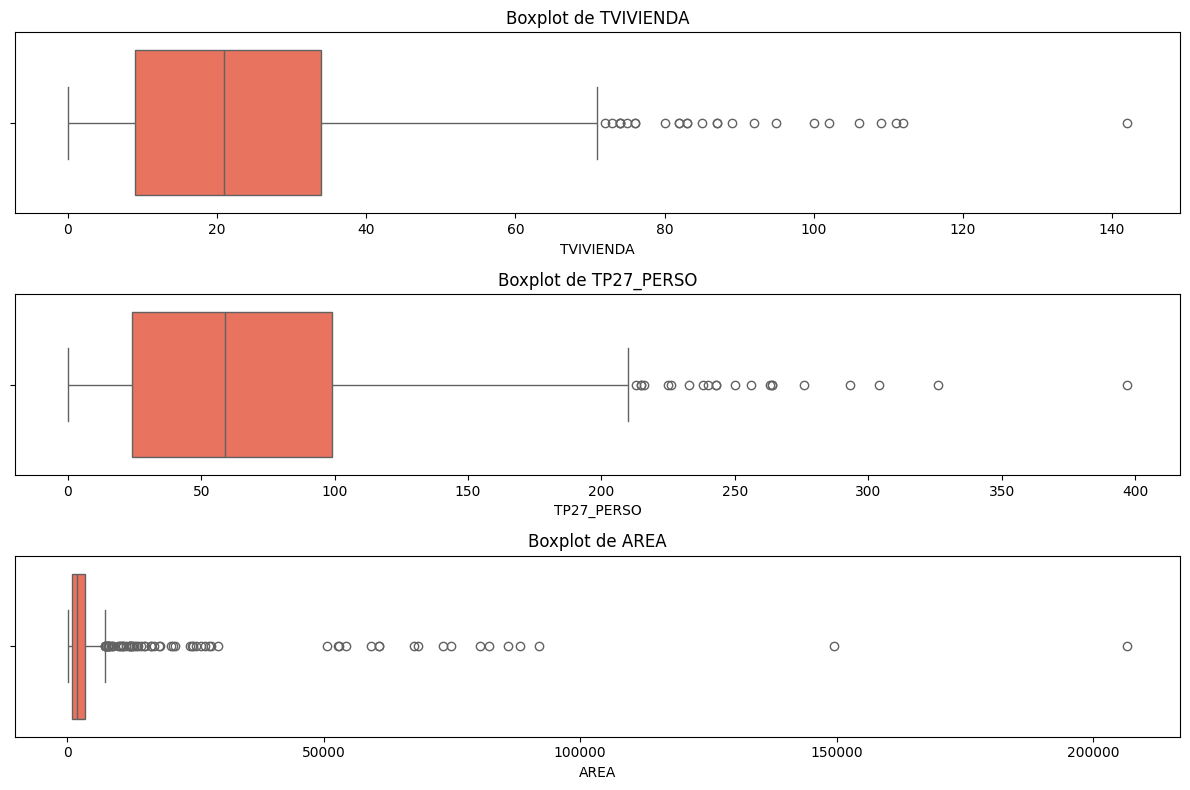

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, var in enumerate(variables):
    sns.boxplot(x=mzn_dane[var], ax=axes[i], color='tomato')
    axes[i].set_title(f'Boxplot de {var}')
    axes[i].set_xlabel(var)

plt.tight_layout()
plt.show()


En la gráfica, los valores atípicos están representados por los círculos que se encuentran fuera de los bigotes del boxplot.

**Observaciones:**

- `TVIVIENDA` y `TP27_PERSO` tienen distribuciones concentradas en valores bajos, con varios valores atípicos hacia la derecha (colas largas).
- `AREA` muestra una gran dispersión y una asimetría considerable, con valores atípicos que están bastante alejados de la media.

Se crea función `detectar_outliers` que identifica valores atípicos en cada variable de interés usando el Rango Intercuartílico (IQR) y agrega una columna booleana (`True` si es un outlier, `False` si no lo es) para cada variable analizada.

In [10]:
def detectar_outliers(gdf, columnas):


    gdf_outliers = gdf.copy()

    for col in columnas:
        Q1 = gdf[col].quantile(0.25)
        Q3 = gdf[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR

        # Crear columna booleana indicando si es un outlier
        gdf_outliers[f'{col}_outlier'] = (gdf[col] < lim_inf) | (gdf[col] > lim_sup)

    return gdf_outliers


In [11]:

variables = ['TVIVIENDA', 'TP27_PERSO', 'AREA']
mzn_outlier = detectar_outliers(mzn_dane, variables)
mzn_outlier.tail()

,TVIVIENDA,TP27_PERSO,AREA,geometry,TVIVIENDA_outlier,TP27_PERSO_outlier,AREA_outlier
617,7.0,13.0,835.825649,"POLYGON ((-75.65146 4.97777, -75.65145 4.97777...",False,False,False
618,1.0,0.0,445.071210,"POLYGON ((-75.60132 4.93126, -75.60132 4.93126...",False,False,False
619,11.0,27.0,1409.787578,"POLYGON ((-75.60112 4.93086, -75.6011 4.93084,...",False,False,False
620,12.0,34.0,2934.797943,"POLYGON ((-75.6006 4.9309, -75.6007 4.93066, -...",False,False,False
621,0.0,0.0,587.300346,"POLYGON ((-75.6006 4.93126, -75.6003 4.93122, ...",False,False,False


In [12]:
TVIVIENDA_outlier=mzn_outlier[mzn_outlier["TVIVIENDA_outlier"]==True][['TVIVIENDA', 'TP27_PERSO', 'AREA']]
print("Cantidad de valores atípicos variable TVIVIENDA",len(TVIVIENDA_outlier))
print("Porcentaje",len(TVIVIENDA_outlier)/len(mzn_dane))
TVIVIENDA_outlier.head()

Cantidad de valores atípicos variable TVIVIENDA 26
Porcentaje 0.04180064308681672


,TVIVIENDA,TP27_PERSO,AREA
42,82.0,225.0,7512.115968
44,142.0,397.0,7094.901869
45,85.0,182.0,7445.023489
46,89.0,198.0,7325.987638
49,72.0,162.0,7440.910958


In [13]:
TP27_PERSO_outlier=mzn_outlier[mzn_outlier["TP27_PERSO_outlier"]==True][['TVIVIENDA', 'TP27_PERSO', 'AREA']]
print("Cantidad de valores atípicos variable TP27_PERSO_outlier",len(TP27_PERSO_outlier))
print("Porcentaje",len(TP27_PERSO_outlier)/len(mzn_dane))
TP27_PERSO_outlier.head()

Cantidad de valores atípicos variable TP27_PERSO_outlier 21
Porcentaje 0.03376205787781351


,TVIVIENDA,TP27_PERSO,AREA
42,82.0,225.0,7512.115968
44,142.0,397.0,7094.901869
173,83.0,263.0,4483.447422
174,102.0,276.0,6311.145754
175,92.0,264.0,6219.974558


In [14]:
AREA_outlier=mzn_outlier[mzn_outlier["AREA_outlier"]==True][['TVIVIENDA', 'TP27_PERSO', 'AREA']]
print("Cantidad de valores atípicos variable AREA_outlier",len(AREA_outlier))
print("Porcentaje",len(AREA_outlier)/len(mzn_dane))
AREA_outlier.head()

Cantidad de valores atípicos variable AREA_outlier 68
Porcentaje 0.10932475884244373


,TVIVIENDA,TP27_PERSO,AREA
5,0.0,0.0,26839.593306
6,46.0,113.0,17844.886650
8,0.0,0.0,16951.099514
9,0.0,0.0,11547.281815
10,1.0,0.0,80378.416964


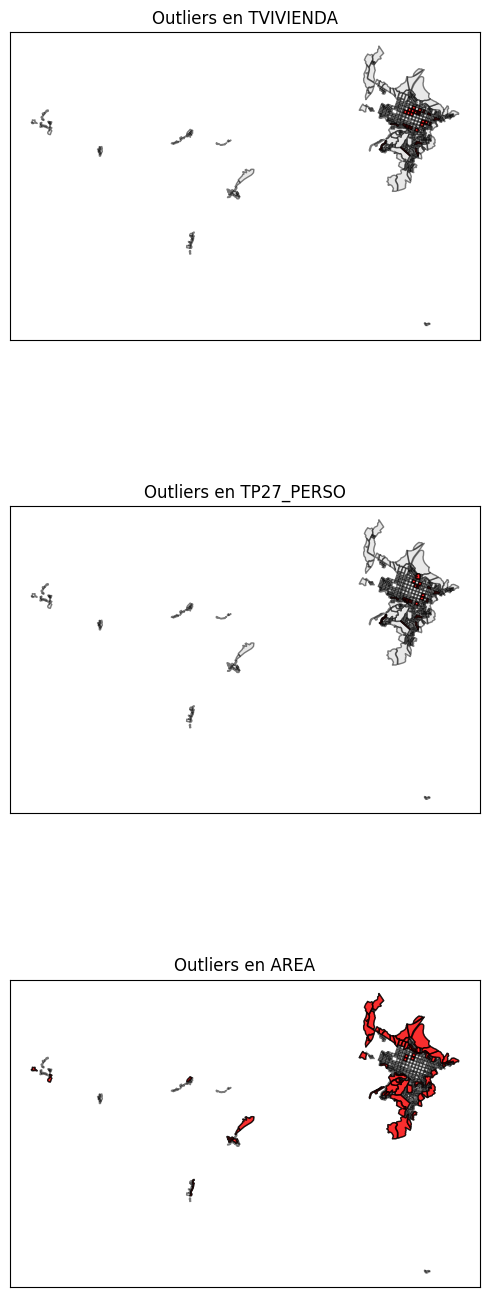

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(5, 15))

# Definir variables de outliers
variable_out = ['TVIVIENDA_outlier', 'TP27_PERSO_outlier', 'AREA_outlier']
titulos = ['Outliers en TVIVIENDA', 'Outliers en TP27_PERSO', 'Outliers en AREA']

for i, var in enumerate(variable_out):
    mzn_outlier.plot(ax=axes[i], color='lightgrey', edgecolor='black', alpha=0.5)

    # Resaltar outliers en rojo
    mzn_outlier[mzn_outlier[var]].plot(ax=axes[i], color='red', edgecolor='black', alpha=0.8)

    axes[i].set_title(titulos[i])
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

In [16]:
# Filtra solo si es outlier en las TRES variables
outliers_todas = mzn_outlier[
    (mzn_outlier["TVIVIENDA_outlier"] == True) &
    (mzn_outlier["TP27_PERSO_outlier"] == True) &
    (mzn_outlier["AREA_outlier"] == True)
][['TVIVIENDA', 'TP27_PERSO', 'AREA']]

# Mostrar resultados
print("Cantidad de outliers en las tres variables:", len(outliers_todas))
print("Porcentaje:", len(outliers_todas) / len(mzn_outlier))
outliers_todas.head()

Cantidad de outliers en las tres variables: 1
Porcentaje: 0.001607717041800643


,TVIVIENDA,TP27_PERSO,AREA
42,82.0,225.0,7512.115968


In [17]:
outliers_alguna = mzn_outlier[
    (mzn_outlier["TVIVIENDA_outlier"] == True) |
    (mzn_outlier["TP27_PERSO_outlier"] == True) |
    (mzn_outlier["AREA_outlier"] == True)
][['TVIVIENDA', 'TP27_PERSO', 'AREA']]

# Mostrar resultados
print("Cantidad de outliers en al menos una variable:", len(outliers_alguna))
print("Porcentaje:", len(outliers_alguna) / len(mzn_outlier))
outliers_alguna.head()

Cantidad de outliers en al menos una variable: 94
Porcentaje: 0.15112540192926044


,TVIVIENDA,TP27_PERSO,AREA
5,0.0,0.0,26839.593306
6,46.0,113.0,17844.886650
8,0.0,0.0,16951.099514
9,0.0,0.0,11547.281815
10,1.0,0.0,80378.416964


La variable `AREA` tiene la mayor cantidad de outliers (10.39%), lo que indica una alta variabilidad en los datos.

Las variables `TVIVIENDA` y `TP27_PERSO` presentan pocos valores atípicos (<5%), por lo que su distribución es más estable.

#### Análisis valores atípicos locales:

Local Outlier Factor (LOF) es un método basado en densidad que permite identificar puntos que están en regiones menos densas en comparación con sus vecinos.

Usaremos LOF para detectar valores atípicos locales en nuestra capa vectorial, analizando múltiples variables al mismo tiempo.

La siguiente función aplica LOF a un conjunto de variables en un GeoDataFrame, creando una nueva columna que indica si una observación es un valores atípicos locales (True) o no (False). los parámetros de la función son:

- `n_neighbors=20`: Define cuántos vecinos cercanos se usan para calcular la densidad local. Un valor mayor suaviza la detección, mientras que uno menor la hace más sensible a cambios locales.
- `contamination=0.05`: Indica que se espera un 5% de outliers en los datos. Si no se conoce este valor, se ajusta según el análisis exploratorio.



In [18]:
from sklearn.neighbors import LocalOutlierFactor

def detectar_outliers_local(gdf, columnas):

    gdf = gdf.copy()
    X = gdf[columnas].fillna(0)
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    gdf["Outlier_local"] = lof.fit_predict(X) == -1
    return gdf

In [19]:
outlier_local2=detectar_outliers_local(mzn_dane, ['TVIVIENDA', 'TP27_PERSO'])
print(len(outlier_local2[outlier_local2["Outlier_local"]== True]))

outlier_local2[outlier_local2["Outlier_local"]== True].head()

32


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,TVIVIENDA,TP27_PERSO,AREA,geometry,Outlier_local
10,1.0,0.0,80378.416964,"POLYGON ((-75.60343 4.9935, -75.60396 4.99284,...",True
44,142.0,397.0,7094.901869,"POLYGON ((-75.60368 4.98532, -75.60366 4.98531...",True
55,34.0,63.0,6374.513232,"POLYGON ((-75.6063 4.98439, -75.60637 4.98422,...",True
57,47.0,88.0,7254.919864,"POLYGON ((-75.60484 4.9833, -75.60485 4.98329,...",True
58,51.0,79.0,7271.966076,"POLYGON ((-75.60389 4.98346, -75.6039 4.98343,...",True


In [20]:
outlier_local3=detectar_outliers_local(mzn_dane, ['TVIVIENDA', 'TP27_PERSO', "AREA"])
print(len(outlier_local3[outlier_local3["Outlier_local"]== True]))
outlier_local3[outlier_local3["Outlier_local"]== True].head()


32


,TVIVIENDA,TP27_PERSO,AREA,geometry,Outlier_local
10,1.0,0.0,80378.416964,"POLYGON ((-75.60343 4.9935, -75.60396 4.99284,...",True
12,10.0,31.0,54411.748402,"POLYGON ((-75.61652 4.99788, -75.61652 4.99792...",True
16,0.0,0.0,68349.351575,"POLYGON ((-75.61406 4.99771, -75.61414 4.99778...",True
19,34.0,74.0,73313.744959,"POLYGON ((-75.61414 4.99573, -75.61418 4.99567...",True
20,27.0,66.0,29426.779686,"POLYGON ((-75.61239 4.99144, -75.61232 4.99158...",True


```{admonition} Nota
:class: tip
 - En Local Outlier Factor (LOF), las variables se interpretan como dimensiones de un vector en un espacio multidimensional.

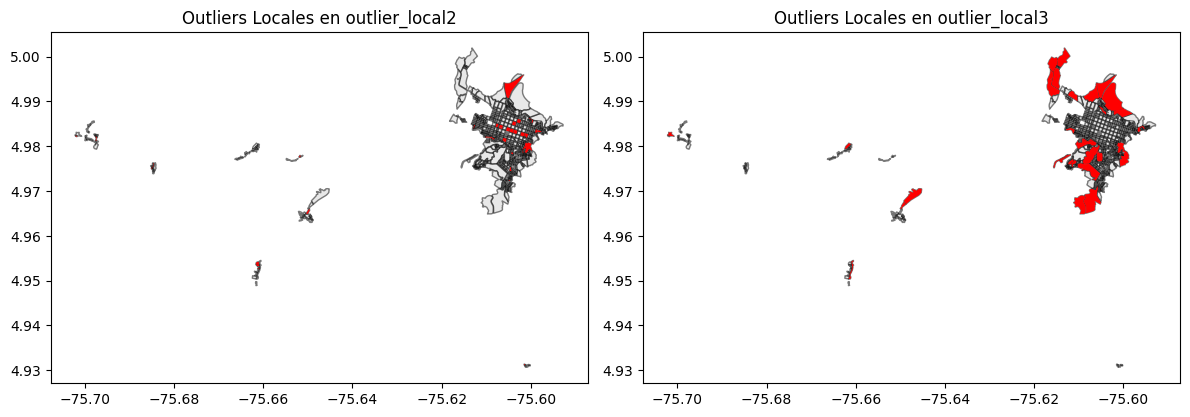

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico 1: Outliers en outlier_local2
outlier_local2.plot(ax=axes[0], color='lightgray', edgecolor='black', alpha=0.5)
outlier_local2[outlier_local2["Outlier_local"] == True].plot(ax=axes[0], color='red', markersize=5)
axes[0].set_title("Outliers Locales en outlier_local2")

# Gráfico 2: Outliers en outlier_local3
outlier_local3.plot(ax=axes[1], color='lightgray', edgecolor='black', alpha=0.5)
outlier_local3[outlier_local3["Outlier_local"] == True].plot(ax=axes[1], color='red', markersize=5)
axes[1].set_title("Outliers Locales en outlier_local3")

plt.tight_layout()
plt.show()


```{admonition} Actividad
:class: important
 Con base en los resultados obtenidos al ejecutar detectar_outliers_local() con diferentes combinaciones de variables,¿Por qué los outliers detectados cambian al incluir la variable 'AREA'?
```

#### Tratamiento de valores atípicos

Existen varias estrategias para manejarlos, dependiendo del contexto y la naturaleza de los datos:

- **Eliminación de outliers**: Se utiliza cuando los valores extremos son errores evidentes o representan una proporción mínima del conjunto de datos. Este método es útil cuando los outliers no aportan información relevante y pueden distorsionar los análisis o modelos predictivos.

- **Sustitución por la mediana**: Como la mediana es menos sensible a valores extremos que la media, reemplazar los outliers por este estadístico permite conservar la estructura general de los datos sin verse afectado por la presencia de valores atípicos.
  
-  **La winsorización**: Limita los valores extremos dentro de un rango determinado en lugar de eliminarlos. Para ello, se reemplazan los valores que están por debajo de un umbral mínimo con el valor del percentil bajo (por ejemplo, el percentil 5), y los que están por encima de un umbral máximo con el valor del percentil alto (como el percentil 95).

In [22]:
outlier_local3[outlier_local3["Outlier_local"]== True]


,TVIVIENDA,TP27_PERSO,AREA,geometry,Outlier_local
10,1.0,0.0,80378.416964,"POLYGON ((-75.60343 4.9935, -75.60396 4.99284,...",True
12,10.0,31.0,54411.748402,"POLYGON ((-75.61652 4.99788, -75.61652 4.99792...",True
16,0.0,0.0,68349.351575,"POLYGON ((-75.61406 4.99771, -75.61414 4.99778...",True
19,34.0,74.0,73313.744959,"POLYGON ((-75.61414 4.99573, -75.61418 4.99567...",True
20,27.0,66.0,29426.779686,"POLYGON ((-75.61239 4.99144, -75.61232 4.99158...",True
21,0.0,0.0,74820.136060,"POLYGON ((-75.6088 4.99094, -75.60881 4.99099,...",True
106,0.0,0.0,85985.123698,"POLYGON ((-75.61435 4.99247, -75.61433 4.99246...",True
155,70.0,194.8,10348.280845,"POLYGON ((-75.61286 4.98364, -75.61284 4.98369...",True
182,70.0,194.8,7956.851079,"POLYGON ((-75.60878 4.98121, -75.60881 4.98136...",True
190,0.0,0.0,88231.567960,"POLYGON ((-75.60562 4.98029, -75.60562 4.98029...",True


```{admonition} Nota: Recuerde
:class: tip
Este análisis evalúa las variables utilizadas para calcular el Índice de Compactación Urbana (ICU) en Chinchiná.
```

**Eliminación de outliers**

Dado que el ICU depende de la relación entre la cantidad de personas y viviendas por manzana, los polígonos sin datos en `STP27_PERS` (número de personas por manzana) y `TVIVIENDA` (conteo de viviendas) no aportan información relevante y pueden excluirse del análisis. Se  elimina las filas donde TVIVIENDA = 0 y TP27_PERSO = 0

In [23]:
mzn_procesada=outlier_local3
print("cantida de registros",len(mzn_procesada))
print("Cantidad de atípicos",len(mzn_procesada[mzn_procesada["Outlier_local"]== True]))


cantida de registros 622
Cantidad de atípicos 32


In [24]:
valores_0=(mzn_procesada["TVIVIENDA"] == 0) & (mzn_procesada["TP27_PERSO"] == 0)&(mzn_procesada['Outlier_local'] == True)
print(len(mzn_procesada[valores_0]))


9


In [25]:
mzn_procesada = mzn_procesada.drop(mzn_procesada[valores_0].index)
print(len(mzn_procesada[mzn_procesada["Outlier_local"]== True]))
mzn_procesada[mzn_procesada["Outlier_local"]== True]

23


,TVIVIENDA,TP27_PERSO,AREA,geometry,Outlier_local
10,1.0,0.0,80378.416964,"POLYGON ((-75.60343 4.9935, -75.60396 4.99284,...",True
12,10.0,31.0,54411.748402,"POLYGON ((-75.61652 4.99788, -75.61652 4.99792...",True
19,34.0,74.0,73313.744959,"POLYGON ((-75.61414 4.99573, -75.61418 4.99567...",True
20,27.0,66.0,29426.779686,"POLYGON ((-75.61239 4.99144, -75.61232 4.99158...",True
155,70.0,194.8,10348.280845,"POLYGON ((-75.61286 4.98364, -75.61284 4.98369...",True
182,70.0,194.8,7956.851079,"POLYGON ((-75.60878 4.98121, -75.60881 4.98136...",True
192,4.0,9.0,163.642707,"POLYGON ((-75.60783 4.98025, -75.60784 4.98025...",True
198,15.0,67.0,8879.411043,"POLYGON ((-75.6128 4.97797, -75.61277 4.978, -...",True
214,70.0,194.8,50601.721349,"POLYGON ((-75.6092 4.98166, -75.60917 4.98171,...",True
218,12.0,42.0,10328.205134,"POLYGON ((-75.61254 4.97795, -75.61252 4.97796...",True


**La winsorización**

Los valores de TVIVIENDA y TP27_PERSO presentan una gran variabilidad, con algunos registros muy por encima del percentil 95 (por ejemplo, TVIVIENDA=332 y TP27_PERSO=688), lo que puede influir desproporcionadamente en análisis estadísticos y modelos predictivos. Winsorizar estos datos reduce su impacto sin eliminarlos. Este método no se aplicará al área de las manzanas (AREA), ya que es una característica geométrica fija que no debe ser modificada.

In [26]:
print(medianas)
info

TVIVIENDA       21.000000
TP27_PERSO      59.000000
AREA          1830.092215
dtype: float64


,TVIVIENDA,TP27_PERSO,AREA
count,622.000000,622.000000,622.000000
mean,25.064309,70.095498,5495.632076
std,22.046336,60.840575,15154.706764
min,0.000000,0.000000,126.092100
25%,9.000000,24.000000,979.459514
50%,21.000000,59.000000,1830.092215
75%,34.000000,99.000000,3560.555261
max,142.000000,397.000000,206593.201361


In [27]:
# Definir los percentiles para winsorización
percentil_5 = mzn_procesada[['TVIVIENDA', 'TP27_PERSO']].quantile(0.05)
percentil_95 = mzn_procesada[['TVIVIENDA', 'TP27_PERSO']].quantile(0.95)
print(percentil_95)

# Filtrar solo los registros con Outlier_local=True
outliers = mzn_procesada['Outlier_local'] == True

# Aplicar winsorización solo a los valores fuera de los percentiles
for col in ['TVIVIENDA', 'TP27_PERSO']:
    mzn_procesada.loc[outliers & (mzn_procesada[col] < percentil_5[col]), col] = percentil_5[col]
    mzn_procesada.loc[outliers & (mzn_procesada[col] > percentil_95[col]), col] = percentil_95[col]

TVIVIENDA      70.0
TP27_PERSO    194.8
Name: 0.95, dtype: float64


In [28]:
mzn_procesada[mzn_procesada["Outlier_local"]== True]

,TVIVIENDA,TP27_PERSO,AREA,geometry,Outlier_local
10,1.0,0.0,80378.416964,"POLYGON ((-75.60343 4.9935, -75.60396 4.99284,...",True
12,10.0,31.0,54411.748402,"POLYGON ((-75.61652 4.99788, -75.61652 4.99792...",True
19,34.0,74.0,73313.744959,"POLYGON ((-75.61414 4.99573, -75.61418 4.99567...",True
20,27.0,66.0,29426.779686,"POLYGON ((-75.61239 4.99144, -75.61232 4.99158...",True
155,70.0,194.8,10348.280845,"POLYGON ((-75.61286 4.98364, -75.61284 4.98369...",True
182,70.0,194.8,7956.851079,"POLYGON ((-75.60878 4.98121, -75.60881 4.98136...",True
192,4.0,9.0,163.642707,"POLYGON ((-75.60783 4.98025, -75.60784 4.98025...",True
198,15.0,67.0,8879.411043,"POLYGON ((-75.6128 4.97797, -75.61277 4.978, -...",True
214,70.0,194.8,50601.721349,"POLYGON ((-75.6092 4.98166, -75.60917 4.98171,...",True
218,12.0,42.0,10328.205134,"POLYGON ((-75.61254 4.97795, -75.61252 4.97796...",True


In [29]:
mzn_procesada.shape

(613, 5)

Para finalizar el proceso, eliminamos la columna Outlier_local, ya que su propósito era identificar valores atípicos, pero no es necesaria en el conjunto de datos final. Luego, guardamos la versión procesada del archivo

In [30]:
mzn_procesada = mzn_procesada.drop(columns=["Outlier_local"])

In [31]:

mzn_procesada.to_file(r"1_insumos/Recursos/mzn_procesada_2.shp")

### Análisis de Resultados

-El tratamiento de valores atípicos requiere estrategias adaptadas según el contexto del análisis. Dependiendo del impacto de los outliers, se pueden eliminar, ajustar o transformar para mejorar la calidad de los dato

-Es importante preservar la integridad de los datos esenciales, no todas las variables deben modificarse. En este caso, el área de las manzanas se mantuvo sin cambios porque representa una característica geométrica fija.



## Referencias

- Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: identifying density-based local outliers. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data* (pp. 93–104).

- Bernardo de Corso Sicilia, G., Pinilla Rivera, M., & Gallego Navarro, J. (2017). Métodos gráficos de análisis exploratorio de datos espaciales con variables espacialmente distribuidas. *Cuadernos Latinoamericanos de Administración*, *13*(25), 92–104. Universidad El Bosque.

- scikit-learn.org. (s.f.). *LOF outlier detection example*. https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_outlier_detection.html